In [7]:
import sys
print(sys.executable)

c:\Users\suvar\chaitra\Job Recruitment Portal - Copy\venv\Scripts\python.exe


In [35]:
import re
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [36]:
project_root = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "dataset" / "Resume.csv").exists()
)

dataset_path = project_root / "dataset" / "Resume.csv"

data = pd.read_csv(dataset_path)

print("Dataset loaded successfully")
print("Path:", dataset_path)

Dataset loaded successfully
Path: c:\Users\suvar\chaitra\Job Recruitment Portal - Copy\dataset\Resume.csv


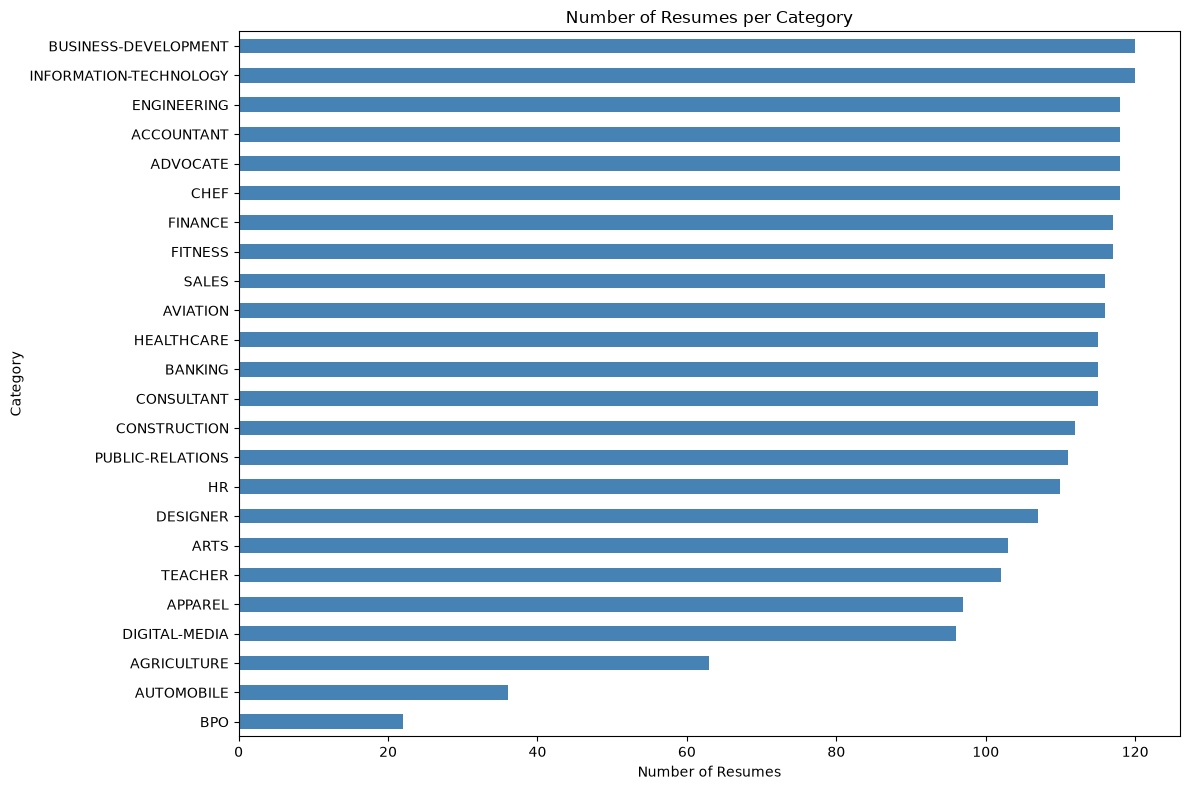

In [47]:
import matplotlib.pyplot as plt

category_counts = data["Category"].value_counts().sort_values()

plt.figure(figsize=(12, 8))
category_counts.plot(kind="barh", color="steelblue")

plt.title("Number of Resumes per Category")
plt.xlabel("Number of Resumes")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [37]:
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())

display(data.head())

Shape: (2484, 4)
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [14]:
print("Columns:", data.columns.tolist())

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']


In [16]:

print("\nMissing values:")
print(data.isnull().sum())


Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [17]:
data["Category"].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [18]:
print(data)

            ID                                         Resume_str  \
0     16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1     22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2     33176873           HR DIRECTOR       Summary      Over 2...   
3     27018550           HR SPECIALIST       Summary    Dedica...   
4     17812897           HR MANAGER         Skill Highlights  ...   
...        ...                                                ...   
2479  99416532           RANK: SGT/E-5 NON- COMMISSIONED OFFIC...   
2480  24589765           GOVERNMENT RELATIONS, COMMUNICATIONS ...   
2481  31605080           GEEK SQUAD AGENT         Professional...   
2482  21190805           PROGRAM DIRECTOR / OFFICE MANAGER    ...   
2483  37473139           STOREKEEPER II       Professional Sum...   

                                            Resume_html  Category  
0     <div class="fontsize fontface vmargins hmargin...        HR  
1     <div class="fontsize fontface

In [38]:
data = data.dropna(subset=["Resume_str", "Category"]).copy()

data["Resume_str"] = (
    data["Resume_str"]
    .astype(str)
    .apply(lambda text: re.sub(r"\s+", " ", text).strip())
)

data = data.drop_duplicates(subset=["Resume_str"])

print("Cleaned dataset shape:", data.shape)

Cleaned dataset shape: (2482, 4)


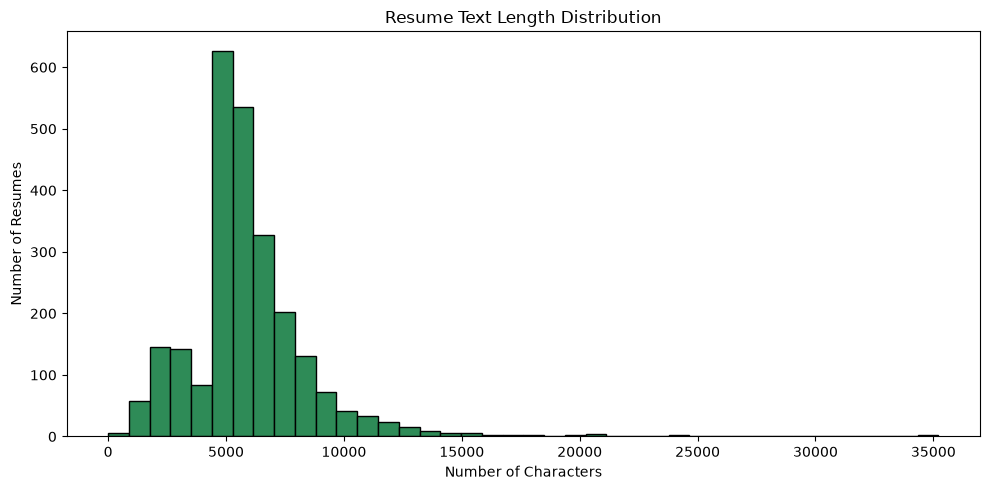

In [48]:
data["Resume_length"] = data["Resume_str"].str.len()

plt.figure(figsize=(10, 5))
plt.hist(data["Resume_length"], bins=40, color="seagreen", edgecolor="black")

plt.title("Resume Text Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Resumes")
plt.tight_layout()
plt.show()

In [39]:
X = data["Resume_str"]
y = data["Category"]

print("Input examples:")
display(X.head())

print("Target examples:")
display(y.head())

Input examples:


0    HR ADMINISTRATOR/MARKETING ASSOCIATE HR ADMINI...
1    HR SPECIALIST, US HR OPERATIONS Summary Versat...
2    HR DIRECTOR Summary Over 20 years experience i...
3    HR SPECIALIST Summary Dedicated, Driven, and D...
4    HR MANAGER Skill Highlights HR SKILLS HR Depar...
Name: Resume_str, dtype: str

Target examples:


0    HR
1    HR
2    HR
3    HR
4    HR
Name: Category, dtype: str

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training resumes:", len(X_train))
print("Testing resumes:", len(X_test))

Training resumes: 1985
Testing resumes: 497


In [41]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB

models = {
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words="english",
            max_features=20000,
            ngram_range=(1, 2)
        )),
        ("classifier", LogisticRegression(max_iter=1000))
    ]),

    "Linear SVC": Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words="english",
            max_features=20000,
            ngram_range=(1, 2)
        )),
        ("classifier", LinearSVC())
    ]),

    "Complement Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words="english",
            max_features=20000,
            ngram_range=(1, 2)
        )),
        ("classifier", ComplementNB())
    ])
}

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []
trained_models = {}

for name, model in models.items():
    print("Training:", name)

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, average="macro", zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, average="macro", zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, predictions, average="macro", zero_division=0
        )
    })

    trained_models[name] = model

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

display(results_df)

Training: Logistic Regression
Training: Linear SVC
Training: Complement Naive Bayes


,Model,Accuracy,Precision,Recall,F1 Score
1,Linear SVC,0.708249,0.703677,0.665746,0.663219
0,Logistic Regression,0.645875,0.622297,0.595317,0.584087
2,Complement Naive Bayes,0.595573,0.621536,0.552323,0.519452


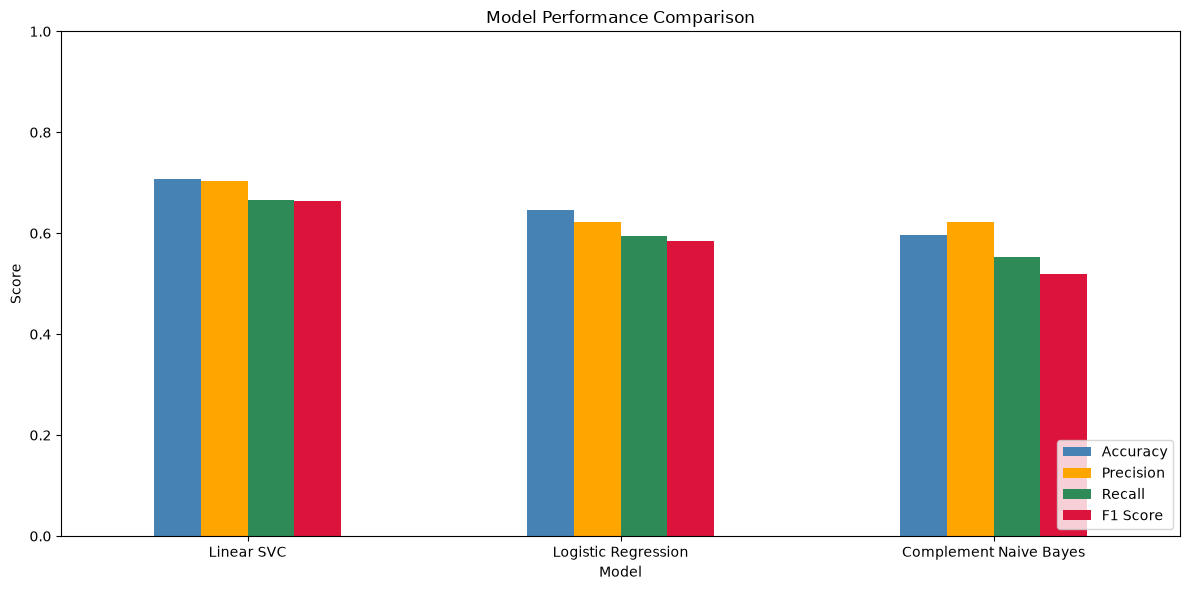

In [49]:
results_plot = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

results_plot.plot(
    kind="bar",
    figsize=(12, 6),
    ylim=(0, 1),
    color=["steelblue", "orange", "seagreen", "crimson"]
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [43]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_predictions = best_model.predict(X_test)

print("Best model:", best_model_name)
print()

Best model: Linear SVC



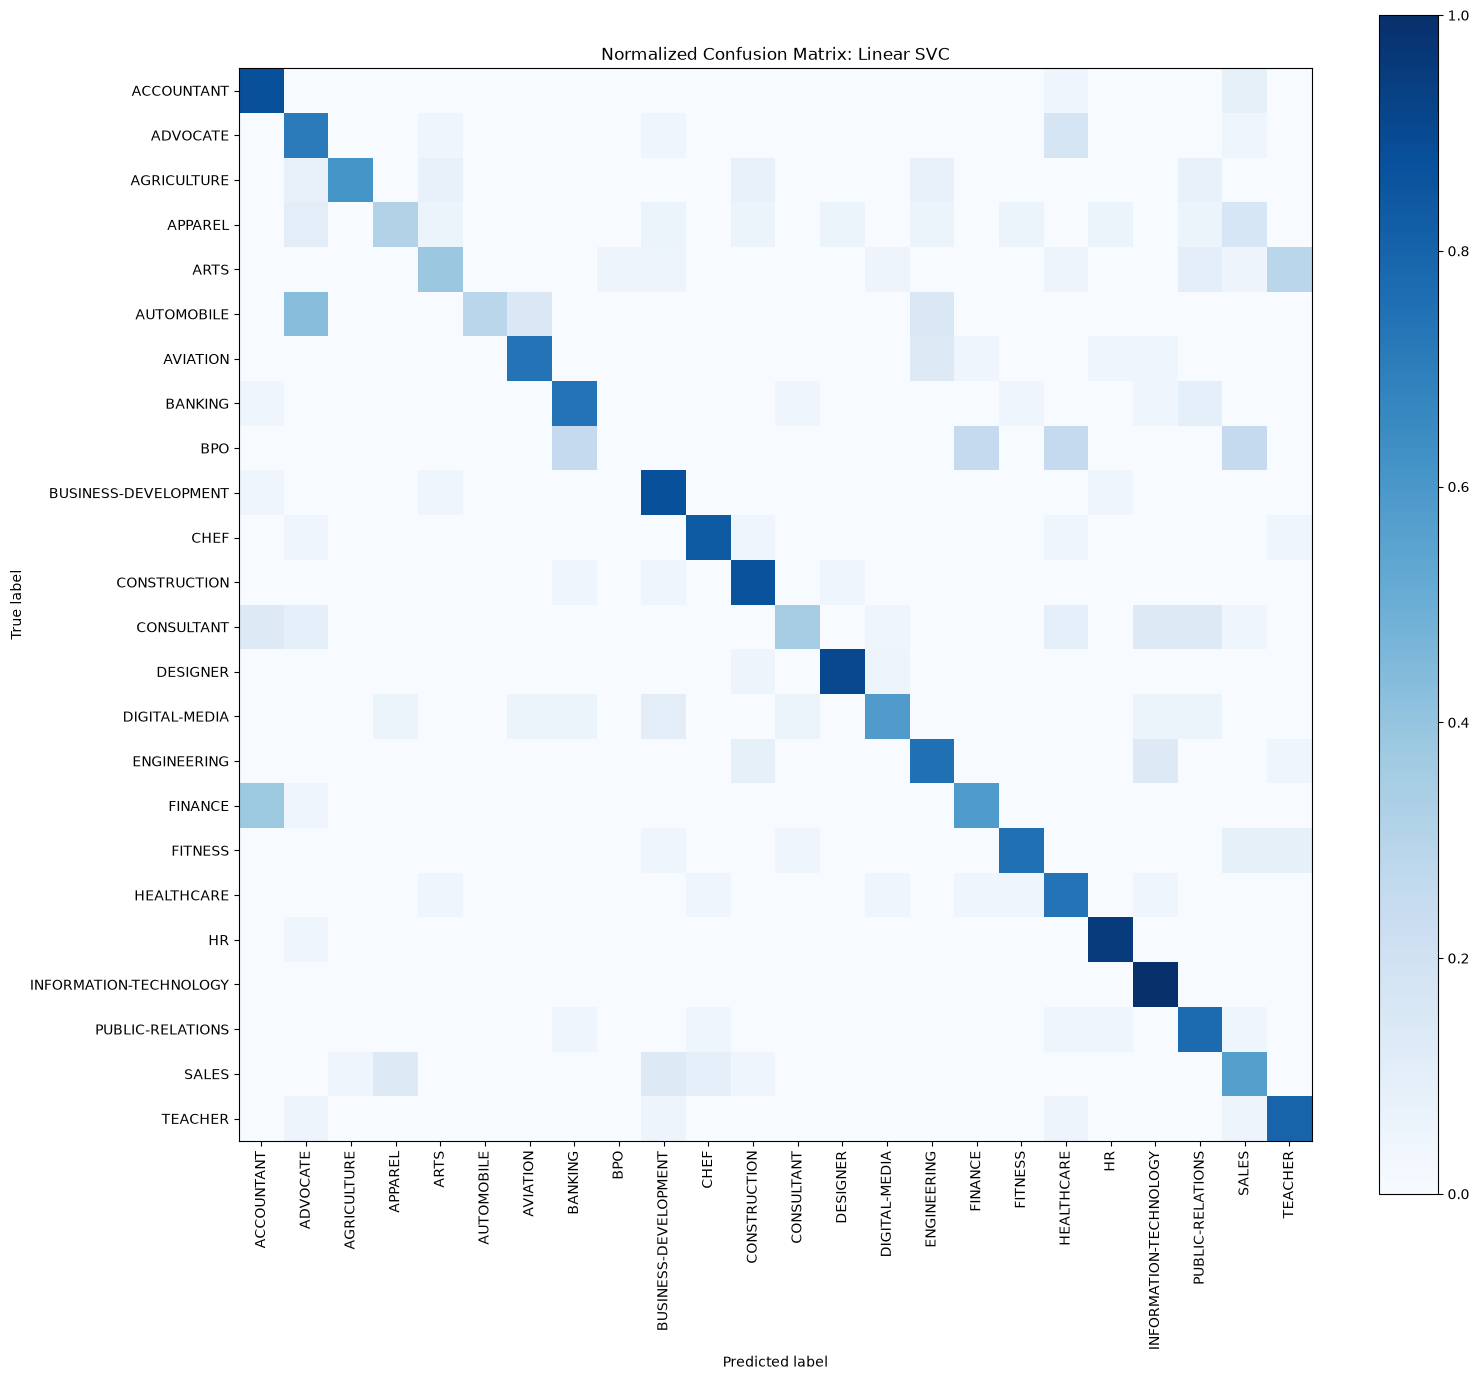

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(16, 14))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    normalize="true",
    include_values=False,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax
)

ax.set_title(f"Normalized Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    best_predictions,
    zero_division=0
))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.60      0.88      0.71        24
              ADVOCATE       0.59      0.71      0.64        24
           AGRICULTURE       0.89      0.62      0.73        13
               APPAREL       0.60      0.32      0.41        19
                  ARTS       0.62      0.38      0.47        21
            AUTOMOBILE       1.00      0.29      0.44         7
              AVIATION       0.89      0.74      0.81        23
               BANKING       0.81      0.74      0.77        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.66      0.88      0.75        24
                  CHEF       0.83      0.83      0.83        24
          CONSTRUCTION       0.73      0.86      0.79        22
            CONSULTANT       0.73      0.35      0.47        23
              DESIGNER       0.90      0.90      0.90        21
         DIGITAL-MEDIA       0.73      

In [45]:
model_path = project_root / "backend" / "resume_classifier.joblib"

joblib.dump(best_model, model_path)

print("Model saved to:")
print(model_path)

Model saved to:
c:\Users\suvar\chaitra\Job Recruitment Portal - Copy\backend\resume_classifier.joblib


In [46]:
sample_resume = """
Human resources professional with experience in recruitment,
employee relations, payroll, and staff management.
"""

predicted_category = best_model.predict([sample_resume])[0]

print("Predicted category:", predicted_category)

Predicted category: HR
